In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\Kehinde\Documents\Data Cleaning\cleaned_cafe_sales.csv")
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,UNKNOWN,2023-03-31
6,TXN_4433211,UNKNOWN,3.0,3.0,9.0,UNKNOWN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,UNKNOWN,5.0,3.0,15.0,UNKNOWN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,UNKNOWN,In-store,2023-12-31


 ### Most Ordered Item In The Coffee Store


In [5]:
item_quantity = df.groupby('Item')['Quantity'].count().reset_index()
item_quantity

,Item,Quantity
0,Cake,1082
1,Coffee,1123
2,Cookie,1035
3,Juice,1124
4,Salad,1099
5,Sandwich,1075
6,Smoothie,1048
7,Tea,1027
8,UNKNOWN,927


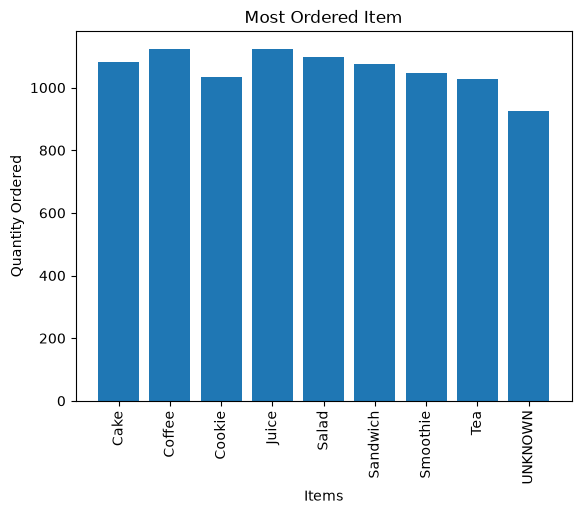

In [6]:
plt.bar( item_quantity['Item'], item_quantity['Quantity'] )
plt.xticks(rotation = 90)
plt.title('Most Ordered Item')
plt.xlabel('Items')
plt.ylabel('Quantity Ordered')
plt.show()



In [7]:
payment_method = df['Payment Method'].value_counts()
payment_method




Payment Method
UNKNOWN           3015
Digital Wallet    2197
Credit Card       2170
Cash              2158
Name: count, dtype: int64

In [8]:
payment_method.index

Index(['UNKNOWN', 'Digital Wallet', 'Credit Card', 'Cash'], dtype='str', name='Payment Method')

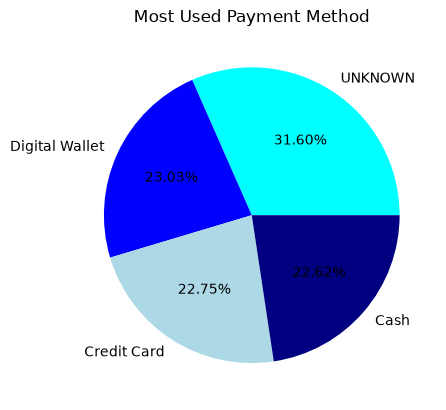

In [9]:
plt.pie(payment_method, labels= payment_method.index, autopct= '%1.2f%%', colors=['cyan', 'blue', 'lightblue', 'navy'])
plt.title('Most Used Payment Method')
plt.show()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9540 non-null   str    
 1   Item              9540 non-null   str    
 2   Quantity          9540 non-null   float64
 3   Price Per Unit    9540 non-null   float64
 4   Total Spent       9540 non-null   float64
 5   Payment Method    9540 non-null   str    
 6   Location          9540 non-null   str    
 7   Transaction Date  9540 non-null   str    
dtypes: float64(3), str(5)
memory usage: 596.4 KB


In [11]:
location_count = df['Location'].value_counts()
location_count

Location
UNKNOWN     3779
Takeaway    2889
In-store    2872
Name: count, dtype: int64

In [12]:
location_count.index

Index(['UNKNOWN', 'Takeaway', 'In-store'], dtype='str', name='Location')

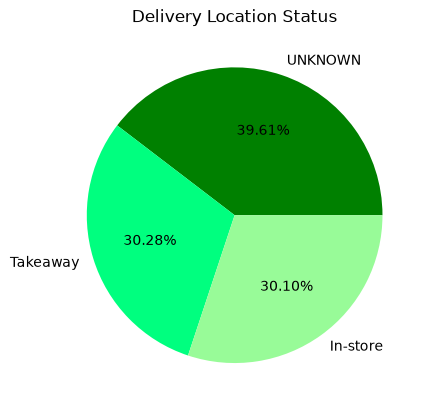

In [13]:
plt.pie(location_count, labels= location_count.index, colors=['green', 'springgreen', 'palegreen'], autopct='%1.2f%%')
plt.title('Delivery Location Status')
plt.show()

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9540 non-null   str    
 1   Item              9540 non-null   str    
 2   Quantity          9540 non-null   float64
 3   Price Per Unit    9540 non-null   float64
 4   Total Spent       9540 non-null   float64
 5   Payment Method    9540 non-null   str    
 6   Location          9540 non-null   str    
 7   Transaction Date  9540 non-null   str    
dtypes: float64(3), str(5)
memory usage: 596.4 KB


In [15]:
df['Transaction Date'].isna().sum()

np.int64(0)

In [16]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   str           
 1   Item              9540 non-null   str           
 2   Quantity          9540 non-null   float64       
 3   Price Per Unit    9540 non-null   float64       
 4   Total Spent       9540 non-null   float64       
 5   Payment Method    9540 non-null   str           
 6   Location          9540 non-null   str           
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 596.4 KB


In [17]:
df['months'] = df['Transaction Date'].dt.month_name()
month_count = df['months'].value_counts()
month_count
money_spent = df['Total Spent'].value_counts

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   str           
 1   Item              9540 non-null   str           
 2   Quantity          9540 non-null   float64       
 3   Price Per Unit    9540 non-null   float64       
 4   Total Spent       9540 non-null   float64       
 5   Payment Method    9540 non-null   str           
 6   Location          9540 non-null   str           
 7   Transaction Date  9540 non-null   datetime64[us]
 8   months            9540 non-null   str           
dtypes: datetime64[us](1), float64(3), str(5)
memory usage: 670.9 KB


In [19]:
month_count.index

Index(['October', 'March', 'June', 'January', 'August', 'December', 'July',
       'September', 'November', 'May', 'April', 'February'],
      dtype='str', name='months')

In [20]:
money_spent = df.groupby('months')['Total Spent'].sum()
money_spent

months
April        6857.193388
August       6777.369013
December     6829.685275
February     6362.844808
January      6890.319266
July         6692.335993
June         7108.584661
March        6849.703327
May          6585.439823
November     6720.530084
October      7019.281415
September    6545.649593
Name: Total Spent, dtype: float64

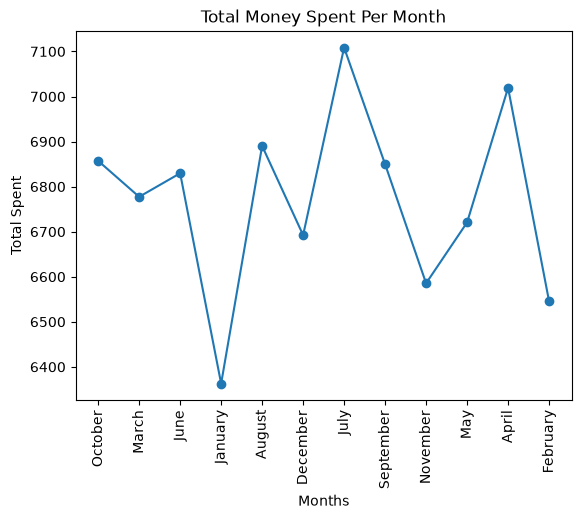

In [21]:
plt.plot(  month_count.index, money_spent, marker ='o' )
plt.title('Total Money Spent Per Month')
plt.xlabel('Months')
plt.ylabel('Total Spent')
plt.xticks(rotation = 90)
plt.show()

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   str           
 1   Item              9540 non-null   str           
 2   Quantity          9540 non-null   float64       
 3   Price Per Unit    9540 non-null   float64       
 4   Total Spent       9540 non-null   float64       
 5   Payment Method    9540 non-null   str           
 6   Location          9540 non-null   str           
 7   Transaction Date  9540 non-null   datetime64[us]
 8   months            9540 non-null   str           
dtypes: datetime64[us](1), float64(3), str(5)
memory usage: 670.9 KB
